# Practice quiz: Advice for applying machine learning


## Question 1

**In the context of machine learning, what is a diagnostic?**

- [ ] A test that you run to gain insight into what is/isn't working with a learning algorithm.
- [ ] An application of machine learning to medical applications, with the goal of diagnosing patients' conditions.
- [ ] A process by which we quickly try as many different ways to improve an algorithm as possible, so as to see what works.
- [ ] This refers to the process of measuring how well a learning algorithm does on a test set (data that the algorithm was not trained on).

### Correct Answer:
**✅ A test that you run to gain insight into what is/isn't working with a learning algorithm.**

### Explanation of Correct Answer:
A **diagnostic** in machine learning is a systematic test designed to reveal specific information about how your learning algorithm is performing. Think of it like a doctor running blood tests to diagnose what's wrong with a patient - you run specific tests to understand the underlying issues affecting your model's performance.

### Explanation of Incorrect Options:

- ❌ *An application of machine learning to medical applications* - This confuses the term "diagnostic" in ML with medical diagnostics. While ML can be used for medical diagnosis, this isn't the technical meaning in the context of debugging ML algorithms.

- ❌ *A process by which we quickly try as many different ways to improve an algorithm as possible* - This describes **brute-force experimentation** or **grid search**, not a diagnostic. Diagnostics are about gaining insight first, then making informed improvements.

- ❌ *This refers to the process of measuring how well a learning algorithm does on a test set* - This describes **model evaluation** or **testing**, which is just one type of measurement. Diagnostics are broader - they help understand *why* performance is what it is.

### Real-World Example:
Imagine you're building a spam email classifier. A diagnostic would be:
- Checking if your model performs worse on emails with attachments vs. plain text emails
- Analyzing which words are most commonly misclassified
- Testing if adding more training data from last month improves accuracy

This is different from just measuring overall accuracy (evaluation) or trying random combinations of features (experimentation).

---

## Question 2

**True/False? It is always true that the better an algorithm does on the training set, the better it will do on generalizing to new data.**

- [ ] False
- [ ] True

### Correct Answer:
**✅ False**

### Explanation:
This statement is **false** because it confuses **training performance** with **generalization**. A model can perform perfectly on training data (even memorizing it) but fail miserably on new data - this is called **overfitting**.

### Why This Matters:
- **High training accuracy ≠ Good test accuracy**
- A model that's too complex can **overfit** - learning noise rather than patterns
- The goal is **generalization**: performing well on unseen data

### Visual Representation:
```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Generate sample data
np.random.seed(42)
X_train = np.linspace(0, 10, 15).reshape(-1, 1)
y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, X_train.shape[0])

X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_test = np.sin(X_test).ravel()

# Create models with different complexity
models = {
    'Underfitting (degree=1)': 1,
    'Good fit (degree=3)': 3,
    'Overfitting (degree=15)': 15
}

plt.figure(figsize=(15, 4))

for i, (title, degree) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    
    # Fit polynomial regression
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    
    # Plot
    plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Training data')
    plt.plot(X_test, model.predict(X_test), color='red', label='Model')
    plt.plot(X_test, np.sin(X_test), '--', color='green', alpha=0.5, label='True function')
    
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    
    plt.title(f'{title}\nTrain R²: {train_score:.3f}, Test R²: {test_score:.3f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

### Key Insight:
- **Underfitting** (degree=1): Poor on both training and test data
- **Good fit** (degree=3): Good balance on both sets
- **Overfitting** (degree=15): Perfect on training, terrible on test data

---

## Question 3

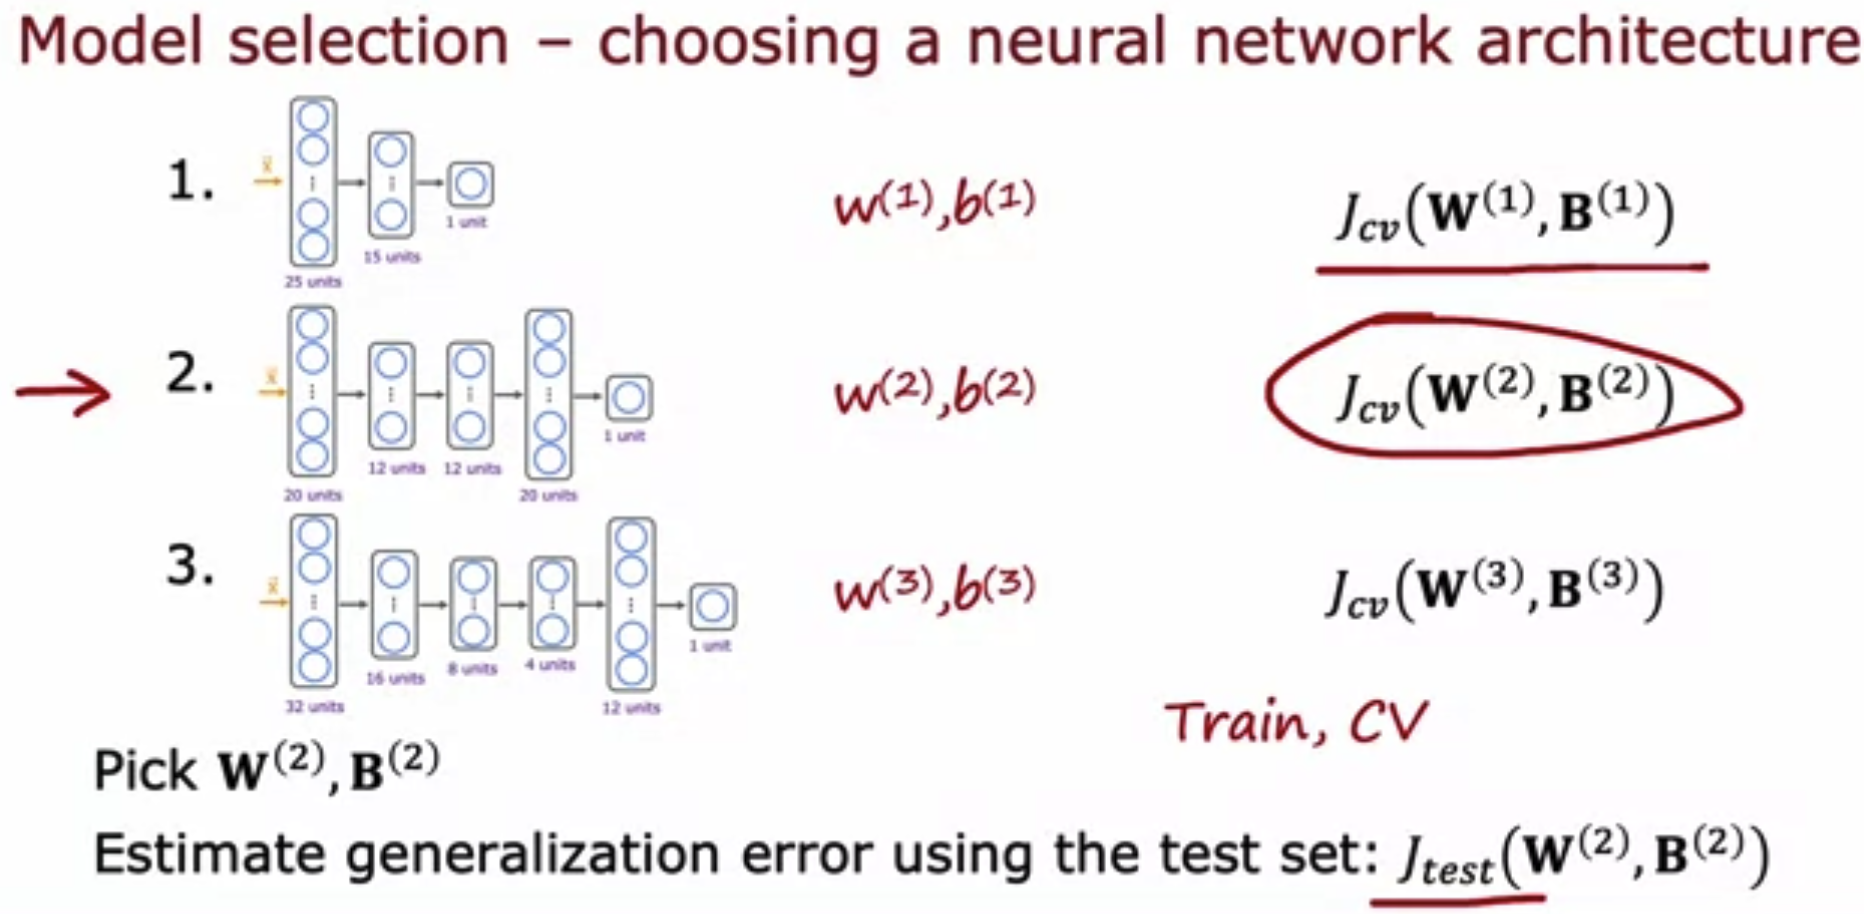

**For a classification task; suppose you train three different models using three different neural network architectures. Which data do you use to evaluate the three models in order to choose the best one?**

- [ ] The cross validation set
- [ ] The test set
- [ ] The training set
- [ ] All the data -- training, cross validation and test sets put together.

### Correct Answer:
**✅ The cross validation set**

### Explanation of Correct Answer:
When selecting between multiple models (also called **model selection**), you use the **cross-validation set** (also called **development set** or **validation set**) to evaluate and compare them.

### Why Not Other Options:

- ❌ *The test set* - This should be kept completely separate until the very end. Using it for model selection would give an overly optimistic estimate of performance and mean you have no data left for final evaluation.

- ❌ *The training set* - This would lead to choosing the most complex model that simply memorized the training data (overfitting), not the one that generalizes best.

- ❌ *All the data together* - This defeats the purpose of having separate datasets. You need:
  - **Training set**: To train the models
  - **Validation/CV set**: To select the best model
  - **Test set**: For final, unbiased evaluation

### The Proper Data Split:
```python
# Visualizing proper data usage in model development
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

# Create boxes for different stages
stages = ['Training', 'Model Selection', 'Final Evaluation']
colors = ['lightgreen', 'lightblue', 'lightcoral']

# Dataset usage
datasets = ['Training Set (60%)', 'CV/Validation Set (20%)', 'Test Set (20%)']
usage = ['Train models', 'Choose best model', 'Final evaluation']

for i, (dataset, use) in enumerate(zip(datasets, usage)):
    ax.barh(i, 1, left=i, color=colors[i], edgecolor='black', height=0.5)
    ax.text(i+0.5, i, f'{dataset}\nUsed for: {use}',
            ha='center', va='center', fontsize=10)

ax.set_xlim(0, 3)
ax.set_ylim(-0.5, 2.5)
ax.set_yticks(range(3))
ax.set_yticklabels(['Step 1', 'Step 2', 'Step 3'])
ax.set_xlabel('Dataset Usage')
ax.set_title('Proper Data Split for Model Development')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
```

### Real-World Example:
Imagine you're a chef developing three new recipes:
- **Training**: You practice making each recipe (like training models)
- **CV/Validation**: Your friends taste and rate all three to pick the best one (model selection)
- **Test**: After picking the winning recipe, you serve it to food critics for final judgment (test set)

You wouldn't ask the critics to taste all three - that would bias their opinion and leave no one for the final verdict!

### Mathematical Notation:
When selecting between models with parameters $(w^{(1)}, b^{(1)})$, $(w^{(2)}, b^{(2)})$, and $(w^{(3)}, b^{(3)})$:

1. Train each model on training set: minimize $J_{train}(w^{(i)}, b^{(i)})$
2. Evaluate on CV set: calculate $J_{cv}(w^{(i)}, b^{(i)})$
3. Select model with lowest $J_{cv}$: $(w^{(best)}, b^{(best)}) = \arg\min_i J_{cv}(w^{(i)}, b^{(i)})$
4. Finally, estimate generalization: $J_{test}(w^{(best)}, b^{(best)})$

---

## Summary Table

| Concept | Purpose | When to Use |
|---------|---------|-------------|
| **Training Set** | Teach the model patterns | During model training |
| **CV/Validation Set** | Model selection & hyperparameter tuning | After training, before final evaluation |
| **Test Set** | Final, unbiased performance estimate | Only once, at the very end |
| **Diagnostic** | Understand model behavior | Whenever you need to debug/improve |

## Key Takeaways

1. **Diagnostics** help you understand *why* your model behaves the way it does
2. **Training performance ≠ Generalization** - always watch for overfitting
3. **Never use test data for model selection** - it's your unbiased final judge
4. Always split your data into **three distinct sets** for proper model development